`Recurrent Neural Network` != `Recursive Neural Network`!

## 1.순환 신경망(Recurrent Neural Network, RNN)
### 1.1 순환 신경망의 특징
- `Feed-Fowrad NN`: 은닉층에서 활성화함수를 지난 값이 출력층으로만 향하는 신경망
- `Recurrent NN`: 은닉층에서 활성화함수를 지난 값이 다시 은닉층의 다음 스텝으로도 향함
- 은닉층에서 활성화 함수를 통해 결과를 내보내는 역할을 하는 노드를 셀(cell)이라고 함
- 이전의 값을 기억하려고 하는 일종의 메모리 역할을 수행
- 셀이 출력층 방향으로 또는 다음 시점 t+1의 자신에게 보내는 값을 은닉 상태(hidden state)라고 함

### 1.2 순환 신경망의 구조
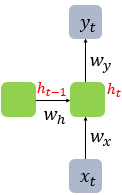
- 은닉층 $h_t = \text{tanh}(W_{x}x_{t}+W_{h}h_{t-1}+b)$
- 출력층 $y_t = f(W_{y}h_{t}+b)$
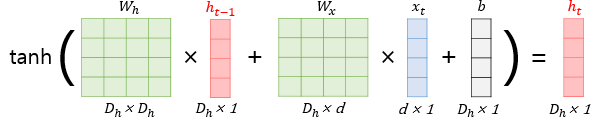
- $W_x, W_h, W_y$는 모든 t에서 동일: 학습은 에포크 단위로 이루어짐
- $h_t$는 t에 따라 변화: 타임스텝별 메모리 역할

## 2. 파이썬으로 RNN 구현하기
- 출력은 생략하고 은닉층의 메모리만 계산

In [23]:
import numpy as np

timesteps = 10 # 시점의 수. NLP에서는 보통 문장의 길이가 된다.
input_size = 4 # 입력의 차원. NLP에서는 보통 단어 벡터의 차원이 된다.
hidden_size = 8 # 은닉 상태의 크기. 메모리 셀의 용량이다.

inputs = np.random.random((timesteps, input_size)) # 입력에 해당되는 2D 텐서

hidden_state_t = np.zeros((hidden_size,)) # 초기 은닉 상태는 0(벡터)로 초기화
# 은닉 상태의 크기 hidden_size로 은닉 상태를 만듬.

In [24]:
print(inputs)        # (10, 4)의 크기를 가지는 입력 텐서
print(hidden_state_t) # 8의 크기를 가지는 은닉 상태. 현재는 초기 은닉 상태로 모든 차원이 0의 값을 가짐.

[[0.77830007 0.51297555 0.49264591 0.50731332]
 [0.66222902 0.08283456 0.13278857 0.18185934]
 [0.56100337 0.59785876 0.16961933 0.80379831]
 [0.06771996 0.98669377 0.83358549 0.13242301]
 [0.90588309 0.0682083  0.21718363 0.2917737 ]
 [0.40918627 0.42250044 0.14506286 0.87584329]
 [0.0210264  0.34369847 0.93529028 0.31840903]
 [0.20462739 0.16303998 0.95186571 0.16229503]
 [0.96921465 0.99147793 0.55048957 0.33416151]
 [0.16181852 0.99646774 0.74854912 0.63235629]]
[0. 0. 0. 0. 0. 0. 0. 0.]


In [25]:
Wx = np.random.random((hidden_size, input_size))  # (8, 4)크기의 2D 텐서 생성. 입력에 대한 가중치.
Wh = np.random.random((hidden_size, hidden_size)) # (8, 8)크기의 2D 텐서 생성. 은닉 상태에 대한 가중치.
b = np.random.random((hidden_size,)) # (8,)크기의 1D 텐서 생성. 이 값은 편향(bias).

In [26]:
print(np.shape(Wx))
print(np.shape(Wh))
print(np.shape(b))

(8, 4)
(8, 8)
(8,)


In [27]:
total_hidden_states = []

# 메모리 셀 동작
for input_t in inputs: # 각 시점에 따라서 입력값이 입력됨.
  output_t = np.tanh(np.dot(Wx,input_t) + np.dot(Wh,hidden_state_t) + b) # Wx * Xt + Wh * Ht-1 + b(bias)
  total_hidden_states.append(list(output_t)) # 각 시점의 은닉 상태의 값을 계속해서 축적
  print(f'메모리 셀 크기: {np.shape(total_hidden_states)}') # 각 시점 t별 메모리 셀의 출력의 크기는 (timestep, output_dim)
  hidden_state_t = output_t

total_hidden_states = np.stack(total_hidden_states, axis = 0)
# 출력 시 값을 깔끔하게 해준다.

print(f'total hideen states=\n{total_hidden_states}') # (timesteps, output_dim)의 크기. 이 경우 (10, 8)의 크기를 가지는 메모리 셀의 2D 텐서를 출력.

메모리 셀 크기: (1, 8)
메모리 셀 크기: (2, 8)
메모리 셀 크기: (3, 8)
메모리 셀 크기: (4, 8)
메모리 셀 크기: (5, 8)
메모리 셀 크기: (6, 8)
메모리 셀 크기: (7, 8)
메모리 셀 크기: (8, 8)
메모리 셀 크기: (9, 8)
메모리 셀 크기: (10, 8)
total hideen states=
[[0.97012057 0.92946991 0.97365024 0.939985   0.91334552 0.97515871
  0.9568392  0.91776899]
 [0.99999547 0.99972307 0.99981859 0.99963461 0.99985716 0.99920792
  0.9999025  0.99976856]
 [0.99999959 0.99993686 0.99995842 0.99993564 0.99995141 0.99983585
  0.99996973 0.99996588]
 [0.99999961 0.99985727 0.99995865 0.99993232 0.99996205 0.99967704
  0.99994122 0.99998596]
 [0.99999812 0.99990413 0.99991096 0.99986178 0.99993668 0.9996398
  0.99995543 0.99990179]
 [0.99999946 0.99992212 0.99994443 0.99991681 0.99993054 0.99974789
  0.99996493 0.99994767]
 [0.9999992  0.99986982 0.99993705 0.99992313 0.99993211 0.99930602
  0.99994135 0.99996827]
 [0.99999874 0.99986761 0.99992501 0.99991011 0.99993144 0.99920013
  0.99993858 0.99995789]
 [0.99999974 0.99996145 0.99998082 0.99997047 0.99998359 0.999931

## 3. 파이토치의 nn.RNN()

In [28]:
import torch
import torch.nn as nn

In [29]:
input_size = 5 # 입력의 크기
hidden_size = 8 # 은닉 상태의 크기

In [30]:
# (batch_size, time_steps, input_size)
inputs = torch.Tensor(1, 10, input_size) # 배치 크기가 1이고, 시점이 10, 입력 크기가 5인 3D 텐서

print(f'input tensor: \n{inputs}') # 입력 텐서의 크기 출력

input tensor: 
tensor([[[-1.0607e-22,  4.5612e-41,  6.6621e-22,  0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 2.6302e+20,  6.1949e-04,  6.4805e-10,  2.5205e-09,  1.0255e-08],
         [ 6.9118e-04,  6.7735e-10,  1.7565e-04,  6.4097e-10,  1.4580e-19],
         [ 1.1495e+24,  3.0956e-18,  9.6635e-06,  4.4152e-05,  1.3039e-11],
         [ 4.3961e-05,  6.8621e-07,  4.4150e-05,  6.3077e-10,  1.0979e-05],
         [ 8.4642e-07,  3.1197e-18,  3.1360e+27,  7.0800e+31,  3.1095e-18],
         [ 4.7851e+22,  2.8826e+32,  4.4248e+30,  7.2442e+22,  2.3086e-12],
         [ 7.1760e+22,  7.2250e+28,  1.5766e-19,  3.3855e-06,  6.6473e+22],
         [ 3.4150e-06,  1.6130e-07,  1.0015e-11,  2.0316e+20,  2.7327e-06]]])


In [31]:
cell = nn.RNN(input_size, hidden_size, batch_first=True)
outputs, _status = cell(inputs)

In [32]:
print(outputs.shape) # 모든 time-step의 hidden_state
print(_status.shape) # 최종 time-step의 hidden_state

torch.Size([1, 10, 8])
torch.Size([1, 1, 8])


## 4. 깊은 순환 신경망(Deep Recurrent Neural Network)

In [33]:
# (batch_size, time_steps, input_size)
inputs = torch.Tensor(1, 10, input_size) # 배치 크기가 1이고, 시점이 10, 입력 크기가 5인 3D 텐서

In [34]:
cell = nn.RNN(input_size = input_size, hidden_size = 8, num_layers = 2, batch_first=True)
outputs, _status = cell(inputs)

In [36]:
print(outputs.shape) # 모든 time-step의 hidden_state
print(_status.shape) # (층의 개수, 배치 크기, 은닉 상태의 크기)

torch.Size([1, 10, 8])
torch.Size([2, 1, 8])


## 5. 양방향 순환 신경망(Bidirectional Recurrent Neural Network)
- RNN은 과거 시점(time step)의 데이터들을 참고해서, 찾고자하는 정답을 예측
- 그러나 시계열이 아닌 시퀀스 자료형(문장 등)에서는 이후 시점의 값이 현재의 값에 영향을 미치기도 함
- 이후 시점의 데이터도 힌트로 활용하기 위해서 고안된 것

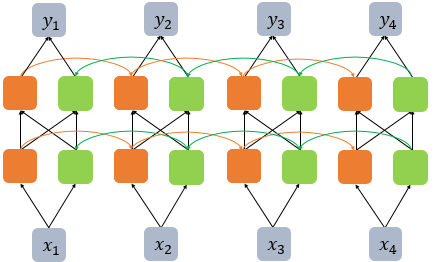

- 정방향 시퀀스에 대한 메모리 셀과 역방향 시퀀스에 대한 메모리 셀, 두 종류의 셀로 구성됨
- 두 종류의 셀이 모두 계산된 뒤 이를 이용해 출력값을 계산
- nn.RNN()의 인자인 bidirectional에 값을 True로 전달하여 구현

In [37]:
# (batch_size, time_steps, input_size)
inputs = torch.Tensor(1, 10, input_size) # 배치 크기가 1이고, 시점이 10, 입력 크기가 5인 3D 텐서

In [38]:
cell = nn.RNN(input_size = input_size, hidden_size = 8, num_layers = 2, batch_first=True, bidirectional = True)
outputs, _status = cell(inputs)

In [39]:
print(outputs.shape) # (배치 크기, 시퀀스 길이, 은닉 상태의 크기 x 2)
print(_status.shape) # (층의 개수 x 2, 배치 크기, 은닉 상태의 크기)

torch.Size([1, 10, 16])
torch.Size([4, 1, 8])
